# Intro
This notebook is intended to query InfluxDB to pull "conntrack" firewall records and display them in 3D. Install the InfluxDB Add-on/Application from here: https://github.com/hassio-addons/addon-influxdb

It depends on a "conntrack" table in Influx being populated by a firewall that tracks connections and bandwidth by source and destination IP.  You can run a Python script on a Linux based firewall (for example an OpenWRT firewall) to regularly pull conntrack information and write it to your InfluxDB.  An example script is provided below.  The widget-based interface of this notebook can be included into Home Assistant using Voila.


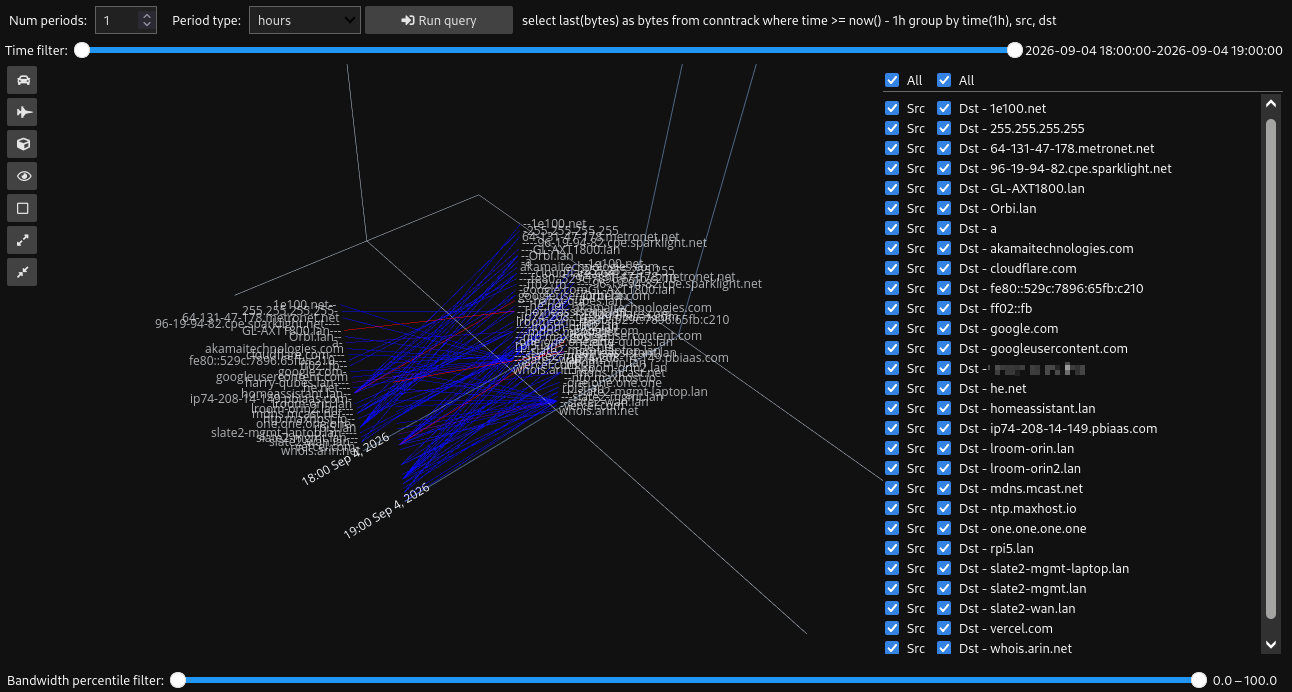

## Data loader script to run on your firewall

This script should run as a deamon on your Linux-based firewall.  There is an example startup script in the section below.

It needs the **influxdb** Python library to be installed on the firewall.

I call this script **```/usr/local/bin/conntrack_to_influxdb.py```**

```python
#!/usr/bin/env python


import subprocess
import xmltodict
import socket
from influxdb import InfluxDBClient
import time

influx_client = InfluxDBClient(host='999.999.999.999', port=8086, username='INFLUX_UID', password='INFLUX_PWD', database='INFLUX_DB')

# A cache of ip addresses to hostnames
ip_2_hostname = {}

def get_hostname(ip):
    if ip in ip_2_hostname:
        return ip_2_hostname[ip]

    try:
        hostname = socket.gethostbyaddr(ip)[0]
    except:
        hostname = ip

    ip_2_hostname[ip] = hostname

    return hostname
  

while True:
    
    (exitcode, output) = subprocess.getstatusoutput("conntrack -L -o xml")

    if exitcode != 0:
        continue

    output_lines = output.split('\n')
    cleaned_output_lines = output_lines[:-1]
    output = '\n'.join(cleaned_output_lines)

    try:
        conntrack_output = xmltodict.parse(output)
    except Exception as parse_error:
        continue

    conntrack_points = []
    
    conntrack = conntrack_output.get('conntrack', {})
    
    flow = conntrack.get('flow', [])
    
    num_sub_items = 0
    for item in flow:
        for sub_item in item.get('meta', {}):
            num_sub_items += 1
            if 'layer4' in sub_item:
                protoname = sub_item['layer4']['@protoname']

                src_ip = sub_item['layer3']['src']
                # Your firewall might have some hardcoded hostnames, so let's resolve them here
                # since it would not be possible to resolve them elsewhere.
                src = get_hostname(src_ip)

                dst_ip = sub_item['layer3']['dst']
                # Your firewall might have some hardcoded hostnames, so let's resolve them here
                # since it would not be possible to resolve them elsewhere.
                dst = get_hostname(dst_ip)

                num_bytes = int(sub_item['counters']['bytes'])
                num_packets = int(sub_item['counters']['packets'])

                if protoname in ('tcp', 'udp'):
                    sport = sub_item['layer4']['sport']
                    dport = sub_item['layer4']['dport']

                else:
                    sport = ''
                    dport = ''

                point_dict = {
                    'measurement': 'conntrack',
                    'tags': {
                        'src': src,
                        'dst': dst,
                        'sport': sport,
                        'dport': dport
                    },
                    'fields': {
                        'bytes': num_bytes,
                        'packets': num_packets
                    }

                }


                conntrack_points.append(point_dict)

        # END for sub_item in item['meta']:
    # END for item in flow:

    try:
        influx_client.write_points(conntrack_points)
        
    except Exception as problem:
        print(problem)
        pass

    time.sleep(60)
```

## Startup script for the data loader

I call the following script **```/usr/local/bin/start_cntrk```**

I start this script from my **```/etc/rc.local```** script.

```bash
#!/bin/sh
CONNTRACK_LOCATION="/usr/local/bin/conntrack_to_influxdb.py"

NUM_CONNTRACKS_RUNNING=`ps | grep $CONNTRACK_LOCATION | grep -v grep | wc -l`
echo "NUM_CONNTRACKS_RUNNING=$NUM_CONNTRACKS_RUNNING"

if [ $NUM_CONNTRACKS_RUNNING -eq 0 ]; then
    echo "Starting $CONNTRACK_LOCATION"
    $CONNTRACK_LOCATION > /dev/null 2> /dev/null < /dev/null &
else
    echo "$CONNTRACK_LOCATION is already running:"
    ps | grep $CONNTRACK_LOCATION | grep -v grep
fi
```

# Imports

In [ ]:
from influxdb import DataFrameClient

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
from pprint import pprint

In [ ]:
import os, copy

In [ ]:
import pandasql
from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())

In [ ]:
import pickle

In [ ]:
import whois

In [ ]:
import plotly.graph_objects as go

In [ ]:
from itertools import cycle, chain

In [ ]:
from datetime import datetime

In [ ]:
import ipywidgets as widgets

In [ ]:
from IPython.display import HTML

In [ ]:
import humanize

# class influx_conntrack_3d

## __init__()

In [ ]:
class influx_conntrack_3d(widgets.VBox):
    def __init__(self, **kwargs):
        self.influx_db_client = self.connect_to_influxdb()

        self.whois_cache_pickle_path = "/config/notebooks/whois_cache.pickle"
        self.whois_cache = self.read_whois_cache()

        # This is normally created in the method query_times_changed_callback() when
        # the query times widgets are changed, but it is pre-seeded here to the default
        # that the query_times_widgets are created with.
        self.sql_statement = f"""select last(bytes) as bytes from conntrack 
        where time >= now() - 1h
        group by time(1h), src, dst"""

        self.query_times_changed = True
        self.ignore_update_trace_calls = False
        
        self.src_dst_filter_widgets = []

        self.query_row = self.create_query_row()
        
        self.time_filter_row = self.create_time_filter_row()

        self.middle_row = self.create_middle_row()

        self.bottom_row = self.create_bottom_row()


        widgets.VBox.__init__(self, [self.query_row, self.time_filter_row, self.middle_row, self.bottom_row], 
                              layout=widgets.Layout(border="0px solid red") )

        self.update_trace()

## connect_to_influxdb()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def connect_to_influxdb(self):
        client = DataFrameClient(host='999.999.999.999', port=8086, username='INFLUX_UID', password='INFLUX_PWD', database='INFLUX_DB')
        return client

## whois_cache

### read_whois_cache()
This notebook depends on Influxdb being populated with sources and destinations that have already had a reverse lookup performed on them at the time that the firewall's conntrack table was dumped to Influxdb. But in cases where the reverse lookup failed and we still only have an IP address instead of a hostname, we can do a whois query. In order to keep this whois query fast, we will cache the results in a pickled dict. 

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def read_whois_cache(self):
        if os.path.isfile(self.whois_cache_pickle_path):
            with open(self.whois_cache_pickle_path, 'rb') as whois_cache_pickle_file:
                whois_cache = pickle.load(whois_cache_pickle_file)

        else:
            whois_cache = {}

        return whois_cache

### debug_dump_whois_cache()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def debug_dump_whois_cache(self, from_disk=False):
        if from_disk == False:
            #pprint(self.whois_cache)
            pass

        else:
            if os.path.isfile(self.whois_cache_pickle_path):
                with open(self.whois_cache_pickle_path, 'rb') as whois_cache_pickle_file:
                    whois_cache = pickle.load(whois_cache_pickle_file)
                    #pprint(self.whois_cache)

### write_whois_cache()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def write_whois_cache(self):
        with open(whois_cache_pickle_path, 'wb') as whois_cache_pickle_file:
            pickle.dump(whois_cache, whois_cache_pickle_file)

### cached_whois_lookup()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def cached_whois_lookup(self, ip):
        ret_val = self.whois_cache.get(ip, '')
        if ret_val != '':
            return ret_val
        
        w = whois.whois(ip)
    
        ret_val = w.get('domain_name', '')
        if ret_val is None:
            ret_val = ''
    
        ret_val = ret_val.lower()
    
        if ret_val == '':
            ret_val = w.get('name_servers', [''])
            if ret_val is None:
                ret_val = ''
            else:
                ret_val = ret_val[0]
                
            ret_val = ret_val.lower()
    
        if ret_val == '':
            ret_val = w.get('emails', [''])
            if ret_val is None:
                ret_val = ''
            else:
                ret_val = ret_val[0]
    
            if '@' in ret_val:
                ret_val = ret_val.split('@')[1]
                
            ret_val = ret_val.lower()
    
        if ret_val == '':
            ret_val = ip
    
        self.whois_cache[ip] = ret_val
        
        return ret_val

## Create the GUI

### create_query_row()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_query_row(self):
        self.query_times_widgets = self.create_query_times_widgets()
        self.sql_query_label = widgets.Label(value=self.sql_statement, layout={'border': '0px solid green', 'flex':'1 1 auto',
                                                                              'padding': '0px 0px 0px 5px'})
        
        header_row = widgets.HBox([self.query_times_widgets, self.sql_query_label], layout={'border': '0px solid yellow'})
        return header_row

#### create_query_times_widgets()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_query_times_widgets(self):
        self.num_periods_widget = widgets.BoundedIntText(
            value=1,
            min=1,
            step=1,
            description='Num periods:',
            disabled=False,
            layout={'border': '0px solid red', 'width':'150px'}
        )
        self.num_periods_widget.observe(self.query_times_changed_callback, names='value')

        self.period_type_widget = widgets.Dropdown(
            options=['seconds', 'minutes', 'hours', 'days', 'weeks', 'months', 'years'],
            value='hours',
            description='Period type:',
            disabled=False,
            layout={'border': '0px solid red', 'width':'200px'}
        )
        self.period_type_widget.observe(self.query_times_changed_callback, names='value')
        
        self.run_query_button = widgets.Button(
            description='Run query:',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Run Query',
            icon='sign-in' # (FontAwesome names without the `fa-` prefix)
        )
        self.run_query_button.on_click(self.update_trace)


        query_times_widgets = widgets.HBox([self.num_periods_widget, self.period_type_widget, self.run_query_button])
        return query_times_widgets

#### query_times_changed_callback()
See the list of [Influxdb literals](https://docs.influxdata.com/influxdb/v1/query_language/spec/#literals) for the v1.8 database that is available as a HomeAssistant App.

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def query_times_changed_callback(self, *args, **kwargs):
        num_time_periods = self.num_periods_widget.value
        kind_of_time_period = self.period_type_widget.value

        map_to_influxdb_duration = {
            'seconds': (1, 's'),
            'minutes': (1, 'm'),
            'hours'  : (1, 'h'),
            'days'   : (1, 'd'),
            'weeks'  : (1, 'w'),
            'months' : (30, 'd'),
            'years'  : (365, 'd')
        }
        multiplier, unit_string = map_to_influxdb_duration[kind_of_time_period]

        time_cutoff = int(num_time_periods) * multiplier
        time_cutoff_string = f'{time_cutoff}{unit_string}'

        time_grouping_string = f'{multiplier}{unit_string}'

        self.sql_statement = f"""select last(bytes) as bytes from conntrack 
        where time >= now() - {time_cutoff_string}
        group by time({time_grouping_string}), src, dst"""
            
        self.sql_query_label.value = self.sql_statement

        self.query_times_changed = True

### create_time_filter_row()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_time_filter_row(self):
        

        self.time_filter_widget = self.create_time_filter_widget()
        
        top_row = widgets.HBox([self.time_filter_widget])
        return top_row

#### create_time_filter_widget()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_time_filter_widget(self):
        time_filter_widget = widgets.SelectionRangeSlider(
            options=['None'],
            description='Time filter:',
            disabled=False,
            layout={'border': '0px solid red', 'flex':'1 1 auto'},
            style= {'description_width': 'initial'}
        )

        time_filter_widget.add_class("time_filter_widget")
        display(HTML(data="""<style>.time_filter_widget .widget-readout { max-width: fit-content !important; flex-grow: 1 !important; }</style>"""))
        time_filter_widget.observe(self.update_trace, names='index')

        return time_filter_widget

### create_middle_row()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_middle_row(self):
        self.controls_strip = self.create_3D_controls()
        self.scatter3D_plot = self.create_scatter3D_plot()
        self.src_dst_filter, self.src_dst_filter_outer_vbox = self.create_src_dst_filter()

        middle_row = widgets.HBox([self.controls_strip, self.scatter3D_plot, self.src_dst_filter_outer_vbox],
                                 layout = widgets.Layout(width = '100%', 
                                                                   border = '0px solid green', 
                                                                   justify_content='flex-end',
                                                                   align_items='stretch',
                                                                   align_content='stretch'
                                                                  )
                                 )
        return middle_row

#### create_3D_controls()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_3D_controls(self):

        display(HTML(data="""<style>.button3Dcontrol { min-width: 30px !important; max-width: 30px !important; flex-shrink: 0 !important; flex-grow: 0 !important; }</style>"""))

        self.front_view_button = widgets.Button(
            description='',
            disabled=False,
            button_style='',  # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Front view',
            icon='car' # (FontAwesome names without the `fa-` prefix)
        )
        self.front_view_button.add_class("button3Dcontrol")
        self.front_view_button.on_click(self.set_front_view)

        self.side_view_button = widgets.Button(
            description='',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or '' 
            tooltip='Side view',
            icon='fighter-jet' # (FontAwesome names without the `fa-` prefix)
        )
        self.side_view_button.add_class("button3Dcontrol")
        self.side_view_button.on_click(self.set_side_view)

        self.oblique_view_button = widgets.Button(
            description='',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Oblique view',
            icon='cube' # (FontAwesome names without the `fa-` prefix)
        )
        self.oblique_view_button.add_class("button3Dcontrol")
        self.oblique_view_button.on_click(self.set_oblique_view)

        self.perspective_button = widgets.Button(
            description='',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Perspective camera',
            icon='eye' # (FontAwesome names without the `fa-` prefix)
        )
        self.perspective_button.add_class("button3Dcontrol")
        self.perspective_button.on_click(self.set_perspective_projection)

        self.orthographic_button = widgets.Button(
            description='',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Orthographic camera',
            icon='square-o' # (FontAwesome names without the `fa-` prefix)
        )
        self.orthographic_button.add_class("button3Dcontrol")
        self.orthographic_button.on_click(self.set_orthographic_projection)

        self.zoom_in_button = widgets.Button(
            description='',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Zoom in',
            icon='expand' # (FontAwesome names without the `fa-` prefix)
        )
        self.zoom_in_button.add_class("button3Dcontrol")
        self.zoom_in_button.on_click(self.zoom_in)

        self.zoom_out_button = widgets.Button(
            description='',
            disabled=False,
            button_style='', # 'success', 'info', 'warning', 'danger' or ''
            tooltip='Zoom out',
            icon='compress' # (FontAwesome names without the `fa-` prefix)
        )
        self.zoom_out_button.add_class("button3Dcontrol")
        self.zoom_out_button.on_click(self.zoom_out)

        display(HTML(data="""<style>.button3Dcontainer { min-width: 36px !important; max-width: 36px !important; flex-shrink: 0 !important; flex-grow: 0 !important; flex-basis: auto !important; }</style>"""))
        controls_strip = widgets.VBox([self.front_view_button, 
                                       self.side_view_button,
                                       self.oblique_view_button,
                                       self.perspective_button,
                                       self.orthographic_button,
                                       self.zoom_in_button,
                                       self.zoom_out_button
                                      ], 
                                      layout={'border': '0px solid yellow'})
        controls_strip.add_class("button3Dcontainer")
        
        return controls_strip

    def set_front_view(self, *args):
        if self.scatter3D_plot.layout.scene.camera.projection.type == 'perspective':
            max_time = max(self.df['time']).timestamp() * 1000
            min_time = min(self.df['time']).timestamp() * 1000
            
            eye_x = max(self.df['x_dst'])/2
            eye_z = max(max(self.df['z_src']), max(self.df['z_dst']))/2
            eye_y = max_time + (max_time - min_time)

            max_x = max(self.df['x_dst'])
            min_x = min(self.df['x_src'])
            mid_x = (max_x + min_x)/2.0

            max_z = max_x
            min_z = min_x
            mid_z = mid_x
            
            center_x = max(self.df['x_dst'])/2
            center_z = max(max(self.df['z_src']), max(self.df['z_dst']))/2
            center_y = min_time
    
            self.scatter3D_plot.layout.scene.camera.eye = dict(x = mid_x, y = 55, z = -mid_z)
            self.scatter3D_plot.layout.scene.camera.center = dict(x = mid_x, y = 0, z = -mid_z)
            self.scatter3D_plot.layout.scene.camera.up = dict(x = 0, y = 0, z = 1)

            
        else:
            self.scatter3D_plot.layout.scene.camera.eye = dict(x = .9, y = 2, z = -.8)
            self.scatter3D_plot.layout.scene.camera.center = dict(x = .9, y = 0, z = -.8)
            self.scatter3D_plot.layout.scene.aspectratio = dict(x = 3.509723495382393, y = 7.9766443076872555, z = 3.509723495382393)

            

    def set_side_view(self, *args):
        if self.scatter3D_plot.layout.scene.camera.projection.type == 'perspective':
            max_x = max(self.df['x_dst'])
            min_x = min(self.df['x_src'])
            mid_x = (max_x + min_x)/2.0

            max_z = max_x
            min_z = min_x
            mid_z = mid_x
            
            self.scatter3D_plot.layout.scene.camera.eye = dict(x = 100, y = 0, z = -mid_z)
            self.scatter3D_plot.layout.scene.camera.center = dict(x = 0, y = 0, z = -mid_z)

        else:
            self.scatter3D_plot.layout.scene.camera.eye = dict(x = 2.9, y = 0, z = -.8)
            self.scatter3D_plot.layout.scene.camera.center = dict(x = .9, y = 0, z = -.8)

    def set_oblique_view(self, *args):
        if self.scatter3D_plot.layout.scene.camera.projection.type == 'perspective':
            max_x = max(self.df['x_dst'])
            min_x = min(self.df['x_src'])
            mid_x = (max_x + min_x)/2.0

            max_z = max_x
            min_z = min_x
            mid_z = mid_x
            
            self.scatter3D_plot.layout.scene.camera.eye = dict(x = -mid_x, y = -mid_x, z = max_z)
            self.scatter3D_plot.layout.scene.camera.center = dict(x = mid_x, y = 0, z = -mid_z)
            self.scatter3D_plot.layout.scene.camera.up = dict(x = 0, y = 0, z = 1)

            
            
        else:
            self.scatter3D_plot.layout.scene.camera.eye = dict(x = 2.1, y = 0.62, z = 0.65)
            self.scatter3D_plot.layout.scene.camera.center = dict(x = 0.9, y = 0, z = -.8)

    def set_perspective_projection(self, *args):
        self.scatter3D_plot.layout.scene.camera.projection.type = 'perspective'

    def set_orthographic_projection(self, *args):
        self.scatter3D_plot.layout.scene.camera.projection.type = 'orthographic'

    def add_vecs(self, a, b):
        result_x = a['x'] + b['x']
        result_y = a['y'] + b['y']
        result_z = a['z'] + b['z']
        return dict(x = result_x, y = result_y, z = result_z)
        
    def subtract_vecs(self, a, b):
        result_x = a['x'] - b['x']
        result_y = a['y'] - b['y']
        result_z = a['z'] - b['z']
        return dict(x = result_x, y = result_y, z = result_z)
        
    def scale_vec(self, s, a):
        result_x = s * a['x']
        result_y = s * a['y']
        result_z = s * a['z']
        return dict(x = result_x, y = result_y, z = result_z)
        
    def zoom_in(self, *args):
        if self.scatter3D_plot.layout.scene.camera.projection.type == 'perspective':
            v = self.subtract_vecs(self.scatter3D_plot.layout.scene.camera.eye, self.scatter3D_plot.layout.scene.camera.center)
            new_v = self.scale_vec(0.9, v)
            new_eye = self.add_vecs(self.scatter3D_plot.layout.scene.camera.center, new_v)
            self.scatter3D_plot.layout.scene.camera.eye = new_eye
        else:
            # From https://github.com/plotly/plotly.py/issues/2474#issuecomment-1543864268
            # Get and set the aspect ratio of the scene
            x_aspect = self.scatter3D_plot.layout.scene.aspectratio.x
            y_aspect = self.scatter3D_plot.layout.scene.aspectratio.y
            z_aspect = self.scatter3D_plot.layout.scene.aspectratio.z
            
            self.scatter3D_plot.update_layout(
                scene_aspectratio={
                    "x": x_aspect * 1.1,
                    "y": y_aspect * 1.1,
                    "z": z_aspect * 1.1,
                },
            )

    def zoom_out(self, *args):
        if self.scatter3D_plot.layout.scene.camera.projection.type == 'perspective':
            v = self.subtract_vecs(self.scatter3D_plot.layout.scene.camera.eye, self.scatter3D_plot.layout.scene.camera.center)
            new_v = self.scale_vec(1.1, v)
            new_eye = self.add_vecs(self.scatter3D_plot.layout.scene.camera.center, new_v)
            self.scatter3D_plot.layout.scene.camera.eye = new_eye
        else:
            # From https://github.com/plotly/plotly.py/issues/2474#issuecomment-1543864268
            # Get and set the aspect ratio of the scene
            x_aspect = self.scatter3D_plot.layout.scene.aspectratio.x
            y_aspect = self.scatter3D_plot.layout.scene.aspectratio.y
            z_aspect = self.scatter3D_plot.layout.scene.aspectratio.z
            
            self.scatter3D_plot.update_layout(
                scene_aspectratio={
                    "x": x_aspect * 0.9,
                    "y": y_aspect * 0.9,
                    "z": z_aspect * 0.9,
                },
            )


#### create_scatter3D_plot()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_scatter3D_plot(self):
        fig = go.FigureWidget(data=go.Scatter3d(
            x=pd.Series(dtype=object), 
            y=pd.Series(data=[pd.Timestamp.now()]), 
            z=pd.Series(dtype=object),
            mode='lines',
            opacity = 0.99,
            name=''
        ))
        fig.update_layout(
             template = "plotly_dark",
             scene=dict(
                xaxis_title=' ',
                xaxis_ticks="",
                xaxis_showticklabels=False,
                zaxis_ticks="",
                zaxis_showticklabels=False,
                zaxis_title=' ',
                yaxis_title=' ',
            ),
            margin=dict(l=0, r=0, b=0, t=0)
        )
        # As a solution to this: https://github.com/plotly/plotly.py/issues/4027
        # the below seems to work.
        fig.add_class("scatter3D_plot")
        display(HTML(data="""<style>.scatter3D_plot { min-width: 1px !important;  flex-grow: 1 !important;  flex-shrink: 1 !important;  flex-basis: auto !important;  }</style>"""))

        return fig

#### create_src_dst_filter()
https://ipywidgets.readthedocs.io/en/latest/reference/ipywidgets.html#ipywidgets.widgets.widget_layout.Layout.overflow

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_src_dst_filter(self):       
        self.src_dst_header = widgets.GridspecLayout(1, 2, layout = {'grid-template-columns':'52px auto !important'})
        self.src_dst_header.add_class("src_dst_header")
        display(HTML(data="""<style>.src_dst_header { 
            grid-template-columns: 52px auto !important;  
            flex-grow: 0 !important;
            flex-shrink: 0 !important;
            min-height: 28px !important;
            max-height: 28px !important;
            border-bottom: 1px solid dimgray;
        }</style>"""))
        
        self.all_src = widgets.Checkbox(value=True, description='All', disabled=False, indent=False,
                                             layout={'max_width': 'content', 'width': '50px', 'height': '24px',
                                                    'border':"0px solid cyan", 'padding': '2px', 'margin': '0px',
                                                    'background': 'black'})
        self.all_dst = widgets.Checkbox(value=True, description='All', disabled=False, indent=False,
                                            layout={'max_width': 'content', 'height': '24px',
                                                    'border':"0px solid cyan", 'padding': '2px', 'margin': '0px',
                                                    'background': 'black'})

        self.all_src.observe(self.toggle_all_sources, names='value')
        self.all_dst.observe(self.toggle_all_destinations, names='value')
        
        self.src_dst_header[0, 0] = self.all_src
        self.src_dst_header[0, 1] = self.all_dst

        
        src_dst_filter = widgets.Output(layout={'border': '0px solid magenta', 'min-width': '400px'})
        src_dst_filter.add_class("src_dst_filter_widget")
        display(HTML(data="""<style>.src_dst_filter_widget { 
            flex-grow: 1 !important; 
            overflow: clip !important; 
            padding-bottom: 10px !important; 
        }</style>"""))

        src_dst_filter_outer_vbox = widgets.VBox([self.src_dst_header, src_dst_filter],
                                                layout={'border': '0px solid red', 'overflow': 'clip', 'min-width': '400px', 'max-height': '600px'})
        src_dst_filter_outer_vbox.add_class("src_dst_filter_outer_vbox")
        display(HTML(data="""<style>.src_dst_filter_outer_vbox { 
            flex-grow: 1 !important; 
            flex-shrink: 1 !important; 
            min-width: 400px !important; 
            max-width: 400px !important; 
            max-height: 600px !important;
        }</style>"""))
        
        return src_dst_filter, src_dst_filter_outer_vbox

    def toggle_all_sources(self, *args):
        #print("toggle_all_sources to:", self.all_src.value)
        self.ignore_update_trace_calls = True
        for src, src_filter_widget in self.src_checkboxes.items():
            src_filter_widget.value = self.all_src.value
            
        self.ignore_update_trace_calls = False
        self.update_trace()


    def toggle_all_destinations(self, *args):
        #print("toggle_all_destinations to:", self.all_dst.value)
        self.ignore_update_trace_calls = True
        for dst, dst_filter_widget in self.dst_checkboxes.items():
            dst_filter_widget.value = self.all_dst.value
            
        self.ignore_update_trace_calls = False
        self.update_trace()

### create_bottom_row()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_bottom_row(self):
        self.bandwidth_filter = self.create_bandwidth_filter()

        bottom_row = widgets.HBox([self.bandwidth_filter], layout={'border': '0px solid yellow', 'flex':'1 1 auto'})
        return bottom_row

#### create_bandwidth_filter()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_bandwidth_filter(self):
        bandwidth_filter = widgets.FloatRangeSlider(
            value=[0.0, 100.0],
            min=0,
            max=100.0,
            step=1.0,
            description='Bandwidth percentile filter:',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            readout=True,
            readout_format='.1f',
            layout={'border': '0px solid green', 'flex':'1 1 auto'},
            style= {'description_width': 'initial'}
        )

        bandwidth_filter.observe(self.update_trace, names='value')
        return bandwidth_filter

## update_trace() - called by most GUI changes

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def update_trace(self, *args):
        #print(f"update_trace() {self.ignore_update_trace_calls=}")
        
        if self.ignore_update_trace_calls == True:
            return

        self.ignore_update_trace_calls = True

        query_was_run = False
        if self.query_times_changed == True:
            query_was_run = True

            # Note that run_influxdb_query() sets self.query_times_changed to False,
            # thereby clearing that flag which is used to decide if a query is needed.
            # So, after the call to run_influxdb_query(), the only way to know if a
            # query was run is to keep track of it with a second flag variable called
            # query_was_run
            self.run_influxdb_query()

            # All this only needs to be done if our set of data has changed.
            self.map_ip_addresses_to_domain_names()
            self.create_extra_df_columns()
            self.update_src_dst_filter_widgets()
            self.create_hover_text()


            

        
        bandwidth_filter_mask = self.apply_bandwidth_filter()
        src_dst_filter_mask = self.apply_src_dest_filter()
        time_filter_mask = self.apply_time_filter()
        
        self.filtered_df = self.df[bandwidth_filter_mask & src_dst_filter_mask & time_filter_mask]

        
        # https://community.plotly.com/t/plot-real-time-data/31467
        with self.scatter3D_plot.batch_update():
            xs = list(chain(*zip(self.filtered_df['x_src'], self.filtered_df['x_dst'], cycle([None]))))
            ys = list(chain(*zip(self.filtered_df['time'],  self.filtered_df['time'],  cycle([None]))))
            zs = list(chain(*zip(self.filtered_df['z_src'], self.filtered_df['z_dst'], cycle([None]))))
            colors = list(chain(*zip(self.filtered_df['color'], self.filtered_df['color'], self.filtered_df['color'])))
            text = list(chain(*zip(self.filtered_df['text'], self.filtered_df['text'], self.filtered_df['text'])))
            
            self.scatter3D_plot.data[0].x = xs
            self.scatter3D_plot.data[0].y = ys
            self.scatter3D_plot.data[0].z = zs
            self.scatter3D_plot.data[0].text = text
            self.scatter3D_plot.data[0].hovertemplate = '%{text}'

            self.scatter3D_plot.data[0].line = dict(
                color=colors,
                width=1
            )

        # The annotations must be added AFTER the data, because the autoscaled axes 
        # must be set up before the annotations otherwise they will look crazy.
        if query_was_run:
            # The commented line causes weird artifacts
            #self.scatter3D_plot.update_layout(scene = dict(annotations = self.annotations))
            self.scatter3D_plot.layout.scene.annotations = []
            self.scatter3D_plot.layout.scene.annotations = self.annotations

            # Avoid autoscaled axes, because they make the graph fluctuate weirdly when
            # filters are applied.
            # Also, only change the axis ranges if the underlying query data has shifted

            # X axis ##################################################################################
            self.scatter3D_plot.layout.scene.xaxis.autorange = False
            
            min_x = min(list(self.df['x_src']) + list(self.df['x_dst']))
            max_x = max(list(self.df['x_src']) + list(self.df['x_dst']))
            x_width = max_x - min_x
            x_margin = x_width / 1.0
            expanded_x_width = x_width + x_margin

            self.scatter3D_plot.layout.scene.xaxis.range = [ min_x - x_margin, max_x ]

            # Y axis ##################################################################################
            self.scatter3D_plot.layout.scene.yaxis.autorange = False

            min_y = min(self.df['time'])
            max_y = max(self.df['time'])
            y_width = max_y - min_y
            y_margin = y_width / 1.0
            y_margin = max(y_margin, pd.Timedelta(4, 'hr'))
            expanded_y_width = y_margin + y_width + y_margin
            
            self.scatter3D_plot.layout.scene.yaxis.range = [ min_y - y_margin, max_y + y_margin ]

            # Z axis ##################################################################################
            self.scatter3D_plot.layout.scene.zaxis.autorange = False

            min_z = min(self.df['z_src'])
            max_z = max(self.df['z_src'])
            z_width = max_z - min_z
            z_margin = z_width / 1.0
            expanded_z_width = z_width + z_margin
            
            self.scatter3D_plot.layout.scene.zaxis.range = [ min_z, max_z + z_margin ]

            
            # Set up the tick values ##################################################################################
            self.scatter3D_plot.layout.scene.xaxis.tickmode = 'array'
            #self.scatter3D_plot.layout.scene.xaxis.tickvals = [ min_x, max_x ]
            self.scatter3D_plot.layout.scene.xaxis.tickvals = [  ]
            self.scatter3D_plot.layout.scene.xaxis.showgrid = False

            self.scatter3D_plot.layout.scene.yaxis.tickmode = 'array'
            self.scatter3D_plot.layout.scene.yaxis.tickvals = self.time_periods

            self.scatter3D_plot.layout.scene.zaxis.tickmode = 'array'
            self.scatter3D_plot.layout.scene.zaxis.showgrid = False

            zaxis_tickvals = sorted(list(set(list(self.df['z_src']) + list(self.df['z_dst']))))
            final_zaxis_tickvals = []
            for i, zaxis_tickval in enumerate(zaxis_tickvals):
                if i%5 == 0:
                    final_zaxis_tickvals.append(zaxis_tickval)

            self.scatter3D_plot.layout.scene.zaxis.tickvals = final_zaxis_tickvals

            # Set the aspect ratio of the axes to something we want ####################################################
            self.scatter3D_plot.layout.scene.aspectmode = "manual"
            y_range_in_seconds = ((max_y.timestamp() - min_y.timestamp())/1000.0) * x_width * 1
            
            self.scatter3D_plot.layout.scene.aspectratio = dict(x=expanded_x_width, 
                                                                y=100.0, 
                                                                z=x_width * expanded_z_width / z_width)

            self.scatter3D_plot.layout.scene.camera.center = {'x': (min_x + max_x)/2., 'y':0, 'z': -(min_x + max_x)/2.}
            self.scatter3D_plot.layout.scene.camera.eye = {'x': 2.0 * max_x, 'y': 2.0 * max_x, 'z': 2.0 * max_x}

            
        self.ignore_update_trace_calls = False

### run_influxdb_query() - using values in the query_times_widgets

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def run_influxdb_query(self, *args):

        self.ignore_update_trace_calls = True
        #print("run_influxdb_query()", self.sql_statement)
        # Signal that the query is running
        self.run_query_button.icon = 'clock-o'
        self.run_query_button.description = 'Running query...'
        self.tooltop = 'Please wait...'

        # Run the query
        result = self.influx_db_client.query(self.sql_statement)

        # Signal that the query is done
        self.run_query_button.icon = 'sign-in'
        self.run_query_button.description = 'Run query'
        self.tooltop = 'Run Query'

        # Massage and assemble the results into a single DataFrame
        dfs_to_concat = []
        for key, value_df in result.items():
            if type(key) != tuple:
                continue 
                
            extra_cols = key[1]
            new_value_df = value_df.copy()
        
            if extra_cols[0][1] == extra_cols[1][1]:
                continue 
                
            for extra_col in extra_cols:
                col_name = extra_col[0]
                col_value = extra_col[1]
                new_value_df[col_name] = col_value
        
            dfs_to_concat.append(new_value_df)
        
        
        self.df = pd.concat(dfs_to_concat).dropna().sort_index()

        # Extract all the new unique time periods in the query result
        self.time_periods = self.df.index.unique()

        time_period_strings = []
        for time_period in self.time_periods:
            time_period_str_with_timezone = str(time_period)
            time_period_str, timezone_str = time_period_str_with_timezone.split('+')
            time_period_strings.append(time_period_str)
            
        self.time_period_strings = time_period_strings

        
        # Apply the time periods to the time filter widget
        self.time_filter_widget.options = time_period_strings
        self.time_filter_widget.index = (0, len(self.time_period_strings) - 1)

        self.df.reset_index(inplace=True, names=['time'])

        # Assign the percentile value to each row based on the value of bytes
        self.df['percentile'] = pd.qcut(self.df['bytes'], 100, labels=False, duplicates='drop')

        
        self.query_times_changed = False
        self.ignore_update_trace_calls = False

#### map_ip_addresses_to_domain_names()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def map_ip_addresses_to_domain_names(self):
        self.create_ip_address_to_domain_mapping()
        self.apply_ip_address_to_domain_mapping()

##### create_ip_address_to_domain_mapping()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_ip_address_to_domain_mapping(self):
        self.map_src_dst_to_clean_value = {}

        sources = set(self.df['src'].unique())
        destinations = set(self.df['dst'].unique())
        all_src_dst = sources.union(destinations)

        def this_is_a_bare_ip(ip_or_hostname):
            no_dots = ip_or_hostname.replace('.', '')
            try:
                int(no_dots)
                return True
            except:
                return False

        for machine in all_src_dst:
            clean_value = machine
            
            if this_is_a_bare_ip(machine):
                clean_value = self.cached_whois_lookup(machine)
        
            # If we now really have a host or domain name, truncate away the host portion
            # for some well known domains to leave just a domain name, because the host portion
            # has infinite irrelevant permutations
            if not this_is_a_bare_ip(clean_value):
                component_list = clean_value.split('.')
                try:
                    if component_list[-2] in ('amazonaws', 'googleusercontent', 'cloudflare', 'google', 'akamaitechnologies', '1e100', 'canonical', 'github', 'cloudfront'):
                        clean_value = '.'.join(component_list[-2:])
                except:
                    pass
        
            self.map_src_dst_to_clean_value[machine] = clean_value

##### apply_ip_address_to_domain_mapping()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def apply_ip_address_to_domain_mapping(self):
        self.df['dst'] = self.df['dst'].map(self.map_src_dst_to_clean_value)
        self.df['src'] = self.df['src'].map(self.map_src_dst_to_clean_value)

#### update_src_dst_filter_widgets_grid()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def update_src_dst_filter_widgets(self):
        # Apply the new distinct src dest values to the src dest filter
        for old_src_dest_filter_widget in self.src_dst_filter_widgets:
            old_src_dest_filter_widget.close()
            del old_src_dest_filter_widget

        self.src_dst_filter_widgets = []

        grid = getattr(self, 'src_dst_grid', None)
        if grid is not None:
            grid.close()
            del grid
        
        sources = set(self.df['src'].unique())
        destinations = set(self.df['dst'].unique())
        all_src_dst = sources.union(destinations)

        num_rows = len(all_src_dst)
        
        self.src_dst_filter.clear_output()

        with self.src_dst_filter:
            
            self.src_dst_grid = widgets.GridspecLayout(num_rows, 2, layout = {'grid-template-columns':'52px auto !important'})
            self.src_dst_grid.add_class("src_dst_grid")
            display(HTML(data="""<style>.src_dst_grid { 
                grid-template-columns: 52px auto !important;  
                overflow: auto !important; 
                max-height: 560px !important;
                padding-bottom: 10px !important; 
            }</style>"""))
            self.src_dst_grid.grid_gap = '0px'
            
            self.src_checkboxes = {}
            self.dst_checkboxes = {}
            
            for row, value in enumerate(sorted(all_src_dst)):
                src_filter_widget = widgets.Checkbox(value=True, description='Src', disabled=False, indent=False,
                                                     layout={'max_width': 'content', 'width': '50px', 'height': '20px',
                                                            'border':"0px solid cyan", 'padding': '0px', 'margin': '0px',
                                                            'background': 'black'})
                dst_filter_widget = widgets.Checkbox(value=True, description='Dst - ' + value, disabled=False, indent=False,
                                                    layout={'max_width': 'content', 'height': '20px',
                                                            'border':"0px solid cyan", 'padding': '0px', 'margin': '0px',
                                                            'background': 'black'})

                src_filter_widget.observe(self.update_trace, names='value')
                dst_filter_widget.observe(self.update_trace, names='value')
                
                self.src_checkboxes[value] = src_filter_widget
                self.dst_checkboxes[value] = dst_filter_widget

                self.src_dst_grid[row, 0] = src_filter_widget
                self.src_dst_grid[row, 1] = dst_filter_widget

            self.src_dst_vbox = widgets.VBox([self.src_dst_grid], layout={'overflow': 'clip'})
            # self.src_dst_vbox.add_class("src_dst_vbox")
            # display(HTML(data="""<style>.src_dst_vbox { overflow-y: scroll !important; }</style>"""))
            display(self.src_dst_vbox)
            

####  create_extra_df_columns()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_extra_df_columns(self):
        sources = set(self.df['src'].unique())
        destinations = set(self.df['dst'].unique())
        all_src_dst = sources.union(destinations)

        map_src_dst_to_int_value = dict([ (x[1], x[0]) for x in enumerate(sorted(all_src_dst, reverse=True))])

        self.create_Z_column_for_src_and_dst(map_src_dst_to_int_value)
        self.create_X_column_for_src_and_dst(all_src_dst)
        
        self.create_color_column()

        self.annotations = self.create_annotations_instead_of_tick_marks(map_src_dst_to_int_value)

        #print(self.df.head())
        


##### create_Z_column_for_src_and_dst()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_Z_column_for_src_and_dst(self, map_src_dst_to_int_value):
        self.df['z_src'] = self.df['src'].map(map_src_dst_to_int_value)
        self.df['z_dst'] = self.df['dst'].map(map_src_dst_to_int_value)

##### create_X_column_for_src_and_dst()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_X_column_for_src_and_dst(self, all_src_dst):
        self.df['x_src'] = len(all_src_dst)
        self.df['x_dst'] = 0

##### create_color_column()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_color_column(self):
        
        max_bytes = max(self.df['bytes'])

        def calculate_color_from_bytes(bytes_value, low_color = (0, 0, 255), high_color = (255, 0, 0), min_alpha = 0.05, max_bytes = max_bytes):
            ratio = bytes_value / max_bytes
        
            c = [0, 0, 0]
            for i in (0, 1, 2):
                c[i] = ratio * (high_color[i] - low_color[i]) + low_color[i]
        
            return f"rgba({c[0]:0.2f}, {c[1]:0.2f}, {c[2]:0.2f}, {max(min_alpha, ratio**5):0.2f})"
            
        def calculate_color_from_percentile(percentile_value, low_color = (0, 0, 255), high_color = (255, 0, 0), min_alpha = 0.05, max_bytes = max_bytes):
            ratio = percentile_value / 100.0
        
            c = [0, 0, 0]
            for i in (0, 1, 2):
                c[i] = ratio * (high_color[i] - low_color[i]) + low_color[i]
        
            return f"rgba({c[0]:0.2f}, {c[1]:0.2f}, {c[2]:0.2f}, {max(min_alpha, ratio**1):0.2f})"
            
        def calculate_color_and_alpha_from_bytes_and_percentile(bytes_value, percentile_value, 
                                                                low_color = (0, 0, 255), high_color = (255, 0, 0), 
                                                                min_alpha = 0.05, max_bytes = max_bytes):
            color_ratio = bytes_value / max_bytes
            alpha_ratio = percentile_value / 100.0
        
            c = [0, 0, 0]
            for i in (0, 1, 2):
                c[i] = color_ratio * (high_color[i] - low_color[i]) + low_color[i]
        
            return f"rgba({c[0]:0.2f}, {c[1]:0.2f}, {c[2]:0.2f}, {max(min_alpha, alpha_ratio**1):0.2f})"
            
        # https://stackoverflow.com/a/52854800
        self.df['color'] = self.df.apply(lambda row: calculate_color_and_alpha_from_bytes_and_percentile(row.bytes, row.percentile), axis=1)

##### create_annotations_instead_of_tick_marks()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_annotations_instead_of_tick_marks(self, map_src_dst_to_int_value):
        # For some reason, the annotations are being displayed 4 hours back from their requested time location.
        # So, add 4 hours to their time to get them back to where they should be.
        min_time = (min(self.df['time']).timestamp() + 4 * 3600) * 1000
        max_time = (max(self.df['time']).timestamp() + 4 * 3600) * 1000

        self.min_time = min_time
        self.max_time = max_time
        
        max_x = max(self.df['x_dst'])
        min_x = min(self.df['x_src'])

        
        annotations = []
        for hostname, z_value in map_src_dst_to_int_value.items():
            # Front right
            annotation = dict(
                    showarrow=False,
                    x=0,
                    y=max_time,
                    z=z_value,
                    #text="-" * (z_value %5) + hostname + " front right",
                    text="-" * (z_value %5) + hostname ,
                    xanchor="left",
                    #xshift=10,
                    opacity=0.7)
        
            annotations.append(annotation)

            # Back right
            annotation = dict(
                    showarrow=False,
                    x=0,
                    y=min_time,
                    z=z_value,
                    #text="-" * (z_value %5) + hostname + " back right",
                    text="-" * (z_value %5) + hostname ,
                    xanchor="left",
                    #xshift=10,
                    opacity=0.7)
        
            annotations.append(annotation)

            # Back left
            annotation = dict(
                    showarrow=False,
                    x=min_x,
                    y=min_time,
                    z=z_value,
                    #text="back left " + hostname + "-" * (z_value %5),
                    text=hostname + "-" * (z_value %5),
                    xanchor="right",
                    #xshift=10,
                    opacity=0.7)
        
            annotations.append(annotation)

        return annotations

#### create_hover_text()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def create_hover_text(self):
        # Create a column with the desired hover text
        self.df['text'] = '<b>SRC:</b> ' + self.df['src'] + '<br><b>DST:</b> ' + self.df['dst'] + \
        '<br><b>Time:</b> ' + self.df['time'].dt.strftime('%a %Y-%m-%d %H:%M') + '<br><b>Data:</b> ' + \
        self.df['bytes'].apply(humanize.filesize.naturalsize) + '<br>x_src: ' + self.df['x_src'].astype(str) + \
        ' z_src: ' + self.df['z_src'].astype(str) + ' x_dst: ' + self.df['x_dst'].astype(str) + \
        ' z_dst: ' + self.df['z_dst'].astype(str)


### apply_bandwidth_filter()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def apply_bandwidth_filter(self):
        filter_min, filter_max = self.bandwidth_filter.value
        return (self.df['percentile'] >= filter_min) & (self.df['percentile'] <= filter_max)


### apply_src_dest_filter()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def apply_src_dest_filter(self):
        src_dst_filter_mask = pd.Series([True] * len(self.df), index = self.df.index)

        num_true_srcs = 0
        for src, src_filter_widget in self.src_checkboxes.items():
            if src_filter_widget.value == False:
                src_dst_filter_mask &= self.df['src'] != src
            else:
                num_true_srcs += 1

        
        for dst, dst_filter_widget in self.dst_checkboxes.items():
            if dst_filter_widget.value == False:
                src_dst_filter_mask &= self.df['dst'] != dst

        
        return src_dst_filter_mask

### apply_time_filter()

In [ ]:
class influx_conntrack_3d(influx_conntrack_3d):
    def apply_time_filter(self):
        filter_min, filter_max = self.time_filter_widget.value
        return (self.df['time'] >= filter_min) & (self.df['time'] <= filter_max)


# Create an instance of influx_conntrack_3d

In [ ]:
widget = influx_conntrack_3d()

In [ ]:
widget